In [1]:
import os
import chromadb
import warnings
warnings.filterwarnings("ignore")
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.schema.runnable import RunnablePassthrough
from langchain.schema.output_parser import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.tools import TavilySearchResults
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent, ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph, MessagesState
from langchain_core.tools import tool
from typing import Literal
from langchain_community.document_loaders import WebBaseLoader, TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import Graph
from langchain.vectorstores import Chroma

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
load_dotenv()

True

In [3]:
embeddings = OpenAIEmbeddings()
parser = StrOutputParser()
llm = ChatOpenAI()

In [4]:
def function1(input1):
    return input1 + "from first function"

def function2(input2):
    return input2 + " and jain from second function"

In [5]:
workflow = Graph()

In [6]:
workflow.add_node("function1", function1)
workflow.add_node("function2", function2)
workflow.add_edge("function1", "function2")
workflow.set_entry_point("function1")
workflow.set_finish_point("function2")


In [7]:
app = workflow.compile()

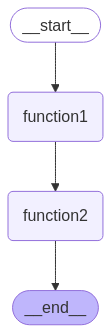

In [8]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [9]:
app.invoke("Hi! It's Shubh")

"Hi! It's Shubhfrom first function and jain from second function"

In [10]:
for output in app.stream("Hi! It's Shubh"):
    for key, value in output.items(): #key is the node name
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from function1
_______
Hi! It's Shubhfrom first function


here is output from function2
_______
Hi! It's Shubhfrom first function and jain from second function




In [11]:
def llm_function(input):
    return llm.invoke(input).content

def upper_case_helper(input):
    return input.upper()

In [12]:
workflow = Graph()
workflow.add_node("llm_function", llm_function)
workflow.add_node("upper_case_helper", upper_case_helper)
workflow.add_edge("llm_function", "upper_case_helper")
workflow.set_entry_point("llm_function")
workflow.set_finish_point("upper_case_helper")
app = workflow.compile()

In [13]:
from IPython.display import Image, display
def displayGraph(app):
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        # This requires some extra dependencies and is optional
        print(e)

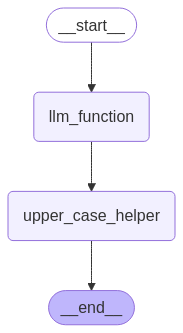

In [14]:
displayGraph(app)

In [15]:
for output in app.stream("Hi! It's Shubh"):
    for key, value in output.items(): #key is the node name
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from llm_function
_______
Hello Shubh! How can I assist you today?


here is output from upper_case_helper
_______
HELLO SHUBH! HOW CAN I ASSIST YOU TODAY?




Workflow2 - RAG

In [16]:
documents = TextLoader("data/state_of_the_union.txt").load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
texts = text_splitter.split_documents(documents)

In [17]:
retriever = FAISS.from_documents(texts, embeddings).as_retriever(search_kwargs={"k": 10})

In [18]:
query = "What did the president say about Ketanji Brown Jackson"
docs = retriever.invoke(query)
docs

[Document(id='5cedd797-bc07-49bf-94e3-b27705ca184a', metadata={'source': 'data/state_of_the_union.txt'}, page_content='One of the most serious constitutional responsibilities a President has is nominating someone to serve on the United States Supreme Court. \n\nAnd I did that 4 days ago, when I nominated Circuit Court of Appeals Judge Ketanji Brown Jackson. One of our nation’s top legal minds, who will continue Justice Breyer’s legacy of excellence.'),
 Document(id='de4f696b-6763-42bb-aabb-36765b9a24fa', metadata={'source': 'data/state_of_the_union.txt'}, page_content='As I said last year, especially to our younger transgender Americans, I will always have your back as your President, so you can be yourself and reach your God-given potential. \n\nWhile it often appears that we never agree, that isn’t true. I signed 80 bipartisan bills into law last year. From preventing government shutdowns to protecting Asian-Americans from still-too-common hate crimes to reforming military justice.')

In [27]:
def reasoning_llm(AgentState):
    print("(1)")
    print(AgentState)
    message = AgentState["messages"]
    question = message[-1]
    complete_prompt="Your task is to provide only the brief answer based on the user query. \
        Don't include too much reasoning. Following is the user query: " + question
    response = llm.invoke(complete_prompt)
    AgentState["messages"].append(response.content) # appending LLM call response to the AgentState
    print("(2)")
    print(AgentState)
    print("(3)")
    return AgentState

def answer_llm(AgentState):
    messages = AgentState['messages']
    question = messages[0] ## Fetching the user question

    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """
    prompt = ChatPromptTemplate.from_template(template)

    retrieval_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
        )
    result = retrieval_chain.invoke(question)
    AgentState["messages"].append(result)
    return AgentState
    

In [28]:
workflow = Graph()
workflow.add_node("reasoning_llm", reasoning_llm)
workflow.add_node("answer_llm", answer_llm)
workflow.add_edge("reasoning_llm", "answer_llm")
workflow.set_entry_point("reasoning_llm")
workflow.set_finish_point("answer_llm")
app = workflow.compile()

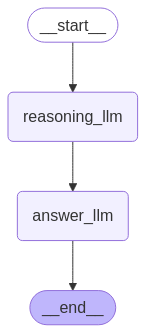

In [21]:
displayGraph(app)

In [22]:
inputs = {"messages": ["What did the president say about Ketanji Brown Jackson?"]}

In [29]:
for output in app.stream(inputs):
    for key, value in output.items(): #key is the node name
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

(1)
{'messages': ['What did the president say about Ketanji Brown Jackson?', "The president praised Ketanji Brown Jackson's qualifications and historic nomination to the Supreme Court.", "The President nominated Circuit Court of Appeals Judge Ketanji Brown Jackson, describing her as one of the nation's top legal minds who will continue Justice Breyer's legacy of excellence.", 'Who did the President nominate for the Supreme Court?  \nJudge Ketanji Brown Jackson.']}
(2)
{'messages': ['What did the president say about Ketanji Brown Jackson?', "The president praised Ketanji Brown Jackson's qualifications and historic nomination to the Supreme Court.", "The President nominated Circuit Court of Appeals Judge Ketanji Brown Jackson, describing her as one of the nation's top legal minds who will continue Justice Breyer's legacy of excellence.", 'Who did the President nominate for the Supreme Court?  \nJudge Ketanji Brown Jackson.', 'Judge Ketanji Brown Jackson.']}
(3)
here is output from reason

Workflow 3 - Agent controlling RAG or LLM call

In [30]:
from typing import TypedDict, Annotated, Sequence
import operator
from langchain_core.messages import BaseMessage
from langchain.prompts import PromptTemplate

In [31]:
operator.add(10, 15)

25

TypedDict:
TypedDict is a Python type hint that allows you to define dictionaries with specific key-value types. It's part of Python's typing module and is particularly useful for type checking and documentation.

BaseMessage:
It's the parent class for all message types in LangChain - HumanMessage, AIMessage, SystemMessage, ToolMessage. It allows for flexibility in handling different types of messages while maintaining type safety.

Sequence:
Supports different types hence making Agent state values much flexible

Annotated:
Annotated is a special type from Python's typing system that allows you to add metadata to type hints.



In [ ]:
#Example
from typing import TypedDict

class Person(TypedDict):
    name: str
    age: int
    is_student: bool

# Valid usage
person1: Person = {
    "name": "Alice",
    "age": 25,
    "is_student": True
}

# Type checker would catch these errors:
person2: Person = {
    "name": "Bob",
    "age": "30",  # Error: age should be int, not str
    "is_student": "yes"  # Error: is_student should be bool, not str
}

In [46]:
person1

{'ascsc': 'Alice', 'age': 25, 'is_student': True}

In [35]:
person2

{'name': 'Bob', 'age': '30', 'is_student': 'yes'}

In [ ]:
#Example
# Different ways to initialize the state
state1: AgentState = {
    "messages": []  # List
}

state2: AgentState = {
    "messages": tuple()  # Tuple
}

state3: AgentState = {
    "messages": deque()  # Deque
}

# All these are valid because they're sequences

In [ ]:
#Example
# Without Annotated
class SimpleState(TypedDict):
    messages: Sequence[BaseMessage]  # Just type information

# With Annotated
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]  # Type + metadata

# Annotated[Type, Metadata1, Metadata2, ...]
# In our case:
Annotated[Sequence[BaseMessage], operator.add]
# - Type: Sequence[BaseMessage]
# - Metadata: operator.add

In [32]:
class AgentState(TypedDict):
    # The 'messages' field should be a sequence of strings, and we annotate it with 'operator.add'
    # This implies we might want to "add" new messages to the sequence later
    messages: Annotated[Sequence[BaseMessage], operator.add]

BaseModel:
BaseModel from Pydantic is a powerful tool for data validation and settings management.

In [ ]:
#Example
from pydantic import BaseModel, EmailStr, Field

class User(BaseModel):
    id: int
    name: str
    email: EmailStr  # Validates email format
    age: int = Field(gt=0, lt=120)  # Age must be between 0 and 120

# Valid data works
user1 = User(id=1, name="Alice", email="alice@example.com", age=25)
print(user1.name)  # Output: Alice

# Invalid data raises validation error
try:
    user2 = User(id="1", name="Bob", email="invalid-email", age=150)
except Exception as e:
    print(f"Validation Error: {e}")

Alice
Validation Error: 2 validation errors for User
email
  value is not a valid email address: An email address must have an @-sign. [type=value_error, input_value='invalid-email', input_type=str]
age
  Input should be less than 120 [type=less_than, input_value=150, input_type=int]
    For further information visit https://errors.pydantic.dev/2.11/v/less_than


In [50]:
class TopicSelectionParser(BaseModel):
    Topic: str = Field(description='Selected Topic')
    Reasoning: str = Field(description='Reasoning behind topic selection')

In [ ]:
#Example
from pydantic import ValidationError

# Valid data
data = {
    "Topic": "Artificial Intelligence",
    "Reasoning": "It's a rapidly growing field with many advancements."
}

# Parsing and validating the data using the Pydantic model
try:
    topic_selection = TopicSelectionParser(**data)
    print(topic_selection.Topic)  # Output: Artificial Intelligence
    print(topic_selection.Reasoning)  # Output: It's a rapidly growing field with many advancements.
except ValidationError as e:
    print(e)

Artificial Intelligence
It's a rapidly growing field with many advancements.


In [ ]:
#Example
# Invalid data (Reasoning is not a string)
invalid_data = {
    "Topic": "Artificial Intelligence",
    "Reasoning": 12345  # Invalid type, should be a string
}

# This will raise a validation error
try:
    topic_selection = TopicSelectionParser(**invalid_data)
    print(topic_selection.Topic)  # Output: Artificial Intelligence
    print(topic_selection.Reasoning)  # Output: It's a rapidly growing field with many advancements.
except ValidationError as e:
    print(e)  # This will print a detailed error message about the invalid field

1 validation error for TopicSelectionParser
Reasoning
  Input should be a valid string [type=string_type, input_value=12345, input_type=int]
    For further information visit https://errors.pydantic.dev/2.11/v/string_type


In [53]:
from langchain.output_parsers import PydanticOutputParser
parser = PydanticOutputParser(pydantic_object=TopicSelectionParser)
parser

PydanticOutputParser(pydantic_object=<class '__main__.TopicSelectionParser'>)

In [54]:
print(parser.get_format_instructions())

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"properties": {"Topic": {"description": "Selected Topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}
```


In [68]:
def agent_helper(state):
    message=state["messages"]
    question=message[-1]
    print(question)
    
    template="""
    Your task is to classify the given user query into one of the following categories: [US Politics Related, Not Related]. 
    Only respond with the category name and nothing else.

    User query: {question}
    {format_instructions}
    """
    
    prompt = PromptTemplate(template=template,
                                    input_variables=[question], # fill values during runtime
                                    partial_variables={         # pre-fill values
                                        "format_instructions" : parser.get_format_instructions()                                    }
                                    )
    chain =  prompt | llm | parser
    
    response = chain.invoke({"question":question })

    print(response)

    return {"messages": [response.Topic]}

In [69]:
state={"messages": ["Tell me about Ketanji Brown Jackson"]}
agent_helper(state)

Tell me about Ketanji Brown Jackson
Topic='US Politics Related' Reasoning='The query is related to a judge nominated by President Biden, which falls under US Politics.'


{'messages': ['US Politics Related']}

In [61]:
def rag_helper(state):
    print('-> Calling RAG ->')
    messages = state['messages']
    question = messages[0] # Fetching the user question

    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """
    prompt = ChatPromptTemplate.from_template(template)

    retrieval_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
        )
    result = retrieval_chain.invoke(question)
    return  {"messages": [result]}

In [70]:
def llm_helper(state):
    print('-> Calling LLM ->')

    messages = state['messages']
    question = messages[0] ## Fetching the user question

    # Normal LLM call
    complete_query = "Anwer the follow question with you knowledge of the real world. Following is the user question: " + question
    response = llm.invoke(complete_query)
    return {"messages": [response.content]}

In [71]:
def router(state):
    print('-> Router ->')
    
    messages = state["messages"]
    last_message = messages[-1]
    print(last_message)
    if 'US Politics Related' in last_message:
        return 'RAG Call'
    else:
        return 'LLM Call'

StateGraph vs Graph:

Use Graph when:
1. Simple linear workflow
2. No need for state management
3. Just passing data between nodes

Use StateGraph when:
1. Complex state management needed
2. Conditional branching
3. Multiple paths in workflow
4. Track conversation history
5. Make decisions based on previous responses
6. Handle multiple paths

In [ ]:
workflow = StateGraph(AgentState)
workflow.add_node("agent", agent_helper)
workflow.add_node("RAG", rag_helper)
workflow.add_node("LLM", llm_helper)
workflow.add_conditional_edges(
    "agent",
    router,
    {
        "RAG Call": "RAG",
        "LLM Call": "LLM",
    }
)
workflow.add_edge("RAG",END)
workflow.add_edge("LLM",END)
workflow.set_entry_point("agent")
app = workflow.compile()

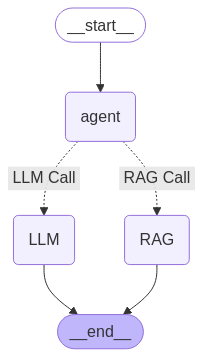

In [75]:
displayGraph(app)

In [76]:
inputs = {"messages": ["What did the president say about Ketanji Brown Jackson"]}
output = app.invoke(inputs)

What did the president say about Ketanji Brown Jackson
Topic='US Politics Related' Reasoning="The query is directly related to the President's statement about a specific individual, indicating a connection to US Politics."
-> Router ->
US Politics Related
-> Calling RAG ->


In [77]:
output

{'messages': ['What did the president say about Ketanji Brown Jackson',
  'US Politics Related',
  "The President nominated Circuit Court of Appeals Judge Ketanji Brown Jackson, describing her as one of our nation's top legal minds who will continue Justice Breyer's legacy of excellence."]}

In [78]:
inputs = {"messages": ["Who has the most number of test centuries in cricket?"]}
output = app.invoke(inputs)

Who has the most number of test centuries in cricket?
Topic='Not Related' Reasoning='The user query is related to cricket statistics, not US politics.'
-> Router ->
Not Related
-> Calling LLM ->


In [79]:
output

{'messages': ['Who has the most number of test centuries in cricket?',
  'Not Related',
  'The player with the most number of test centuries in cricket is Sachin Tendulkar from India. He has scored 51 test centuries in his career.']}